<a href="https://colab.research.google.com/github/Thashmikab/offshore-wind-layout-cable-tradeoff/blob/main/08_turbine_size_optimisation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/Thashmikab/offshore-wind-layout-cable-tradeoff/blob/main/08_turbine_size_optimisation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 08 · Turbine size as a design variable

Notebook 07 with one more variable: turbine capacity from 8 to 12 MW. For each capacity, rotor diameter
and hub height follow the Li et al. (2022) regressions (D = 62.69·C^0.46, H = 4.93·(D²)^0.31), PyWake
builds a matching `GenericWindTurbine`, and a power-law wind shear (α = 0.11) moves the 119 m Global
Wind Atlas wind to each hub height. The number of turbines is round(80 MW / C).

Objectives: maximise full-load hours (AEP per installed MW, so farms of 77–84 MW compare fairly) and
minimise life cycle GWP per MWh. All four impact categories are then calculated along the front.

This notebook needs no ecoinvent licence: it reads the material impact factors that notebook 07 exported to
`data/lca_factors_materials.csv`.

In [1]:
%pip install -q py_wake==2.6.20 topfarm==2.6.2 pymoo==0.6.2

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 717.0/717.0 kB 19.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.0/20.0 MB 63.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 100.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 110.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.5/13.5 MB 90.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 347.2/347.2 kB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 87.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 879.5/879.5 kB 48.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.5/118.5 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from scipy.sparse.csgraph import minimum_spanning_tree
from py_wake.site import XRSite
from py_wake.site.xrsite import GlobalWindAtlasSite
from py_wake.examples.data.dtu10mw import DTU10MW
from py_wake.literature.gaussian_models import Niayifar_PorteAgel_2016
from py_wake.turbulence_models import CrespoHernandez
from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize

FIG = Path("figures"); FIG.mkdir(exist_ok=True)
Path("data").mkdir(exist_ok=True)

In [3]:
#@title Turbine mass model (Li et al., 2022)
# Size relations: Li et al. (2022) SI, Fig. S2 (published equations)
# Component masses: power laws fitted to Li et al. (2022) SI, Fig. S3 (digitised by the author, ~±10%)

def rotor_diameter(C_mw):
    return 62.69 * C_mw ** 0.46

def hub_height(D_m):
    return 4.93 * (D_m ** 2) ** 0.31

def component_masses_t(C_mw, foundation="jacket"):
    D = rotor_diameter(C_mw)
    H = hub_height(D)
    masses = {
        "nacelle": 285 * (D / 148) ** 2.14,           # geared PMSG
        "rotor":   165 * (D / 148) ** 2.56,           # glass-fibre blades + hub
        "tower":   390 * (D**2 * H / 2.3e6) ** 0.69,  # steel tower
    }
    if foundation == "jacket":
        masses["foundation"] = 1150 * (C_mw / 6.5) ** 1.255
    else:
        masses["foundation"] = 1700 * (C_mw / 6.5) ** 1.235   # monopile
    return D, H, masses




# Share of component mass by material class (Li et al. 2022, Table 1)
COMPOSITION = {
    "nacelle":    {"cast_iron": 0.415, "steel_high_alloy": 0.393, "steel_low_alloy": 0.103,
                   "copper": 0.022, "aluminium": 0.009, "electronics": 0.004},   # PMSG-GB
    "rotor":      {"cast_iron": 0.258, "steel_high_alloy": 0.094, "steel_low_alloy": 0.098,
                   "copper": 0.001, "aluminium": 0.001, "glass_fibre": 0.373, "resin": 0.175},
    "tower":      {"steel_low_alloy": 0.971, "copper": 0.009, "aluminium": 0.010, "electronics": 0.010},
    "foundation": {"steel_low_alloy": 0.858, "concrete": 0.142},                  # jacket
}

In [4]:
#@title Material impact factors (exported by notebook 07)
IMPACT_PER_KG = pd.read_csv("https://raw.githubusercontent.com/Thashmikab/offshore-wind-layout-cable-tradeoff/refs/heads/main/data/lca_factors_materials.csv", index_col=0)
METHODS = [col.split(" (")[0] for col in IMPACT_PER_KG.columns]
UNITS = {col.split(" (")[0]: col.split(" (")[1].replace("/kg)", "") for col in IMPACT_PER_KG.columns}
print(IMPACT_PER_KG.round(4).to_string())

                  GWP100 (kg CO2-Eq/kg)  SOP (kg Cu-Eq/kg)  water (m3/kg)  TETP (kg 1,4-DCB-Eq/kg)
material                                                                                          
steel_low_alloy                  2.5666             0.3488         0.0236                  14.2226
steel_high_alloy                 7.9848             0.6452         0.0503                 205.9388
cast_iron                        4.1878             0.4122         0.0231                  21.1420
copper                           8.2903             1.8376         0.1508                3379.6761
aluminium                       15.0434             0.2288         0.0886                  16.9804
glass_fibre                      2.6044             0.0546         0.0162                  28.8849
resin                            5.0032             0.1423         0.0639                  19.3467
electronics                     32.9642             1.5768         0.2850                 552.6970
concrete  

In [5]:
#@title Impacts of one turbine (materials + processing)
PER_KG = {c: IMPACT_PER_KG.iloc[:, i].to_dict() for i, c in enumerate(METHODS)}

def turbine_impacts(C_mw, foundation="jacket"):
    D, H, masses = component_masses_t(C_mw, foundation)
    totals = {c: 0.0 for c in METHODS}
    for component, mass_t in masses.items():
        for material, share in COMPOSITION[component].items():
            for c in METHODS:
                totals[c] += mass_t * 1000 * share * PER_KG[c][material]
    return totals

In [6]:
#@title Cable material inventory from ABB (2010) geometry, per metre
RHO = {"copper": 8960, "lead": 11340, "steel": 7850, "xlpe": 950}   # kg/m3

# ABB "XLPE Submarine Cable Systems" rev 5, three-core cables with lead sheath (Tables 45, 47, 49)
# name: (conductor mm2, conductor dia mm, dia over insulation mm, lead thickness mm, outer dia mm, weight Cu kg/m, armour wire mm)
CABLES = {
    "array_66kV_3x400":   (400, 23.2, 43.6, 1.7, 141, 39.2, 5),
    "export_132kV_3x300": (300, 20.4, 54.8, 2.1, 167, 48.0, 5),
    "export_220kV_3x1000":(1000, 37.9, 87.3, 3.1, 241, 104.0, 6),
}

def cable_materials_kg_per_m(A, d_cond, d_ins, t_lead, OD, weight, wire, serving=4.0, lay=1.03):
    m = {}
    m["copper"] = 3 * A * 1e-6 * RHO["copper"]
    m["xlpe"]   = 3 * np.pi / 4 * (d_ins**2 - d_cond**2) * 1e-6 * RHO["xlpe"]
    m["lead"]   = 3 * np.pi * (d_ins + t_lead) * t_lead * 1e-6 * RHO["lead"]
    D_mean = OD - 2 * serving - wire                                  # armour layer mid-diameter
    m["steel_armour"] = np.pi * D_mean * np.pi * wire / 4 * 1e-6 * RHO["steel"] * lay
    m["polymer_other"] = weight - sum(m.values())                     # fillers, sheaths, serving
    return m

CABLE_KG_PER_M = pd.DataFrame({k: cable_materials_kg_per_m(*v) for k, v in CABLES.items()}).T
print((CABLE_KG_PER_M).round(2).to_string())       # kg/m = t/km

                     copper   xlpe   lead  steel_armour  polymer_other
array_66kV_3x400      10.75   3.05   8.23         12.77           4.40
export_132kV_3x300     8.06   5.79  12.77         15.36           6.01
export_220kV_3x1000   26.88  13.84  29.95         27.17           6.15


In [7]:
#@title Cable impacts per km
CABLE_IMPACT_PER_KM = {
    cable: {c: sum(CABLE_KG_PER_M.loc[cable, m] * 1000 * PER_KG[c][m]      # kg/m -> kg/km
                   for m in CABLE_KG_PER_M.columns)
            for c in METHODS}
    for cable in CABLE_KG_PER_M.index
}
print(pd.DataFrame(CABLE_IMPACT_PER_KM).T.div(1000).round(1).to_string())   # tonnes-eq per km

                     GWP100   SOP  water     TETP
array_66kV_3x400      157.8  26.0    2.4  36998.1
export_132kV_3x300    162.9  23.0    2.3  28215.3
export_220kV_3x1000   406.8  65.4    6.2  92934.5


In [8]:
#@title Farm settings
TI = 0.06
LIFETIME_YR = 25
LEASE_X, LEASE_Y = 3000, 2000
D_REF_KM = 146.65
D_MIN_KM, D_MAX_KM = 10, 150
POP_SIZE, N_GEN, SEED = 80, 100, 1

ARRAY_CABLE = "array_66kV_3x400"
EXPORT_CABLE, EXPORT_SHARE = "export_132kV_3x300", 1.0     # standalone 80 MW farm

In [9]:
DATA = Path("data/dogger_bank_gwa.nc")

def load_dogger_bank_site():
    """Dogger Bank wind climate from the Global Wind Atlas (54.75 N, 1.90 E, 119 m, open sea).
    Downloaded once and cached in data/ so later runs don't depend on the GWA API."""
    if DATA.exists():
        return XRSite(xr.load_dataset(DATA))
    print("Downloading Dogger Bank wind climate from the Global Wind Atlas...")
    site = GlobalWindAtlasSite(lat=54.75, long=1.90, height=119, roughness=0.0002)
    DATA.parent.mkdir(exist_ok=True)
    site.ds.to_netcdf(DATA)
    return site


base_gwa_site = load_dogger_bank_site()

In [10]:
# 1. Load the CSV file once
transect_df = pd.read_csv("https://raw.githubusercontent.com/Thashmikab/offshore-wind-layout-cable-tradeoff/refs/heads/main/data/dogger_bank_transect.csv")

# Extract arrays for blazing-fast numpy operations
KNOWN_DISTANCES = transect_df['distance_km'].values
KNOWN_SCALES    = transect_df['U_rel'].values

def calculate_transect_scale_factor(distance_to_shore_km):
    """
    Empirically scales wind speed based on a Global Wind Atlas transect
    running from the Yorkshire coast out to Dogger Bank.
    """
    # Clip the incoming distance to ensure safe lookup bounds [0, 160]
    query_dist = np.clip(distance_to_shore_km, KNOWN_DISTANCES[0], KNOWN_DISTANCES[-1])

    # Linearly interpolate the scaling factor
    scale_factor = np.interp(query_dist, KNOWN_DISTANCES, KNOWN_SCALES)
    return float(scale_factor)


#print(calculate_transect_scale_factor(10))


In [11]:
#@title Turbine models for each capacity (built once, then reused)
from functools import lru_cache
from py_wake.wind_turbines.generic_wind_turbines import GenericWindTurbine
from py_wake.site.shear import PowerShear

TARGET_MW = 80
C_MIN, C_MAX = 8, 12                          # validity range of the mass model
MAX_TURBINES = int(np.ceil(TARGET_MW / C_MIN)) # 10
SHEAR = PowerShear(h_ref=119, alpha=0.11)      # GWA data are at 119 m; alpha typical offshore

def n_turbines(C):
    return int(round(TARGET_MW / C))

@lru_cache(maxsize=None)
def turbine_model(C):
    D = rotor_diameter(C)
    H = hub_height(D)
    wt = GenericWindTurbine(f"Generic_{C}MW", diameter=D, hub_height=H, power_norm=C * 1000)  # kW
    wf = Niayifar_PorteAgel_2016(base_gwa_site, wt, turbulenceModel=CrespoHernandez())
    return wf, D, H

@lru_cache(maxsize=None)
def turbine_impacts_cached(C):
    return turbine_impacts(C)                  # per turbine, all categories

In [12]:
#@title Objective function (turbine size + layout + distance)
def unpack(v):
    C = int(np.round(v[0]))
    N = n_turbines(C)
    x = np.asarray(v[1 : 1 + MAX_TURBINES])[:N]                     # fixed slots
    y = np.asarray(v[1 + MAX_TURBINES : 1 + 2 * MAX_TURBINES])[:N]
    return C, N, x, y, v[-1]

def evaluate_design(v):
    """variables = [capacity MW, x1..x10, y1..y10, distance to shore km]
    Objectives: maximise full-load hours, minimise GWP per MWh."""
    C, N, x, y, dist_shore_km = unpack(v)
    wf, D, H = turbine_model(C)

    # Energy: wind scaled for distance offshore, sheared to this turbine's hub height
    scaled_ds = base_gwa_site.ds.copy(deep=True)
    scaled_ds["Weibull_A"] = base_gwa_site.ds["Weibull_A"] * calculate_transect_scale_factor(dist_shore_km)
    scaled_ds["TI"] = TI
    wf.site = XRSite(scaled_ds, shear=SHEAR)
    aep_gwh = float(wf(x + dist_shore_km * 1000, y).aep().sum().values)
    full_load_hours = aep_gwh * 1000 / (N * C)

    # Cables
    distances = pdist(np.column_stack([x, y]))
    array_km = minimum_spanning_tree(squareform(distances)).sum() / 1000
    export_km = dist_shore_km

    # Life cycle GWP per MWh
    t = turbine_impacts_cached(C)
    gwp_total = (N * t["GWP100"]
                 + array_km * CABLE_IMPACT_PER_KM[ARRAY_CABLE]["GWP100"]
                 + export_km * EXPORT_SHARE * CABLE_IMPACT_PER_KM[EXPORT_CABLE]["GWP100"])
    gwp_per_mwh = gwp_total / (aep_gwh * 1000 * LIFETIME_YR)

    spacing_violation = 4 * D - distances.min()
    return [-full_load_hours, gwp_per_mwh], spacing_violation

In [13]:
#@title Check each capacity once before optimising
x_pad = np.linspace(0, 2700, 5).repeat(2)        # 10 slots, spread over the lease box
y_pad = np.tile([0, 1800], 5)
for C in range(C_MIN, C_MAX + 1):
    v = np.concatenate([[C], x_pad, y_pad, [50]])
    (neg_flh, gwp), viol = evaluate_design(v)
    wf, D, H = turbine_model(C)
    print(f"{C:2d} MW x {n_turbines(C):2d} | D {D:5.1f} m, H {H:5.1f} m | "
          f"{-neg_flh:,.0f} full-load h | {gwp:5.2f} kg CO2e/MWh | spacing OK: {viol <= 0}")

 8 MW x 10 | D 163.2 m, H 116.1 m | 4,772 full-load h |  8.91 kg CO2e/MWh | spacing OK: True
 9 MW x  9 | D 172.2 m, H 120.0 m | 4,769 full-load h |  8.98 kg CO2e/MWh | spacing OK: False
10 MW x  8 | D 180.8 m, H 123.7 m | 4,766 full-load h |  9.07 kg CO2e/MWh | spacing OK: False
11 MW x  7 | D 188.9 m, H 127.1 m | 4,770 full-load h |  9.17 kg CO2e/MWh | spacing OK: False
12 MW x  7 | D 196.6 m, H 130.3 m | 4,761 full-load h |  9.18 kg CO2e/MWh | spacing OK: False


In [14]:
#@title NSGA-II problem
class WindFarmSizingProblem(ElementwiseProblem):
    def __init__(self):
        lower = [C_MIN] + [0] * MAX_TURBINES + [0] * MAX_TURBINES + [D_MIN_KM]
        upper = [C_MAX] + [LEASE_X] * MAX_TURBINES + [LEASE_Y] * MAX_TURBINES + [D_MAX_KM]
        super().__init__(n_var=len(lower),   # 1 + 10 + 10 + 1 = 22
                         n_obj=2,             # full-load hours, GWP per MWh
                         n_ieq_constr=1,      # spacing
                         xl=lower, xu=upper)

    def _evaluate(self, v, out, *args, **kwargs):
        objectives, spacing_violation = evaluate_design(v)
        out["F"] = objectives
        out["G"] = [spacing_violation]

In [15]:
#@title Run NSGA-II
problem = WindFarmSizingProblem()

rng = np.random.default_rng(SEED)
X0 = rng.uniform(problem.xl, problem.xu, size=(POP_SIZE, problem.n_var))
X0[0] = np.concatenate([[10], x_pad, y_pad, [D_REF_KM]])     # one feasible starting design

N_GEN = 300
POP_SIZE = 100

result = minimize(problem, NSGA2(pop_size=POP_SIZE, sampling=X0),
                  ("n_gen", N_GEN), seed=SEED, verbose=False)

rows = []
for v in result.X:
    C, N, x, y, d = unpack(v)
    (neg_flh, gwp), _ = evaluate_design(v)
    rows.append({"Capacity_MW": C, "N_turbines": N, "Distance_km": d,
                 "Full_load_hours": -neg_flh, "GWP_kg_per_MWh": gwp})
front = pd.DataFrame(rows).sort_values("GWP_kg_per_MWh").reset_index(drop=True)
print(front.round(2).to_string())

    Capacity_MW  N_turbines  Distance_km  Full_load_hours  GWP_kg_per_MWh
0            10           8        14.40          4655.31            8.70
1            10           8        15.44          4663.82            8.70
2            10           8        16.45          4672.02            8.70
3            10           8        16.95          4676.04            8.71
4            10           8        17.46          4679.95            8.71
5            10           8        18.52          4689.43            8.71
6            10           8        18.56          4689.74            8.71
7            10           8        19.35          4696.70            8.71
8            10           8        19.66          4698.72            8.71
9            10           8        20.29          4703.38            8.71
10           10           8        20.68          4706.56            8.71
11           10           8        21.28          4711.86            8.71
12           10           8        21.

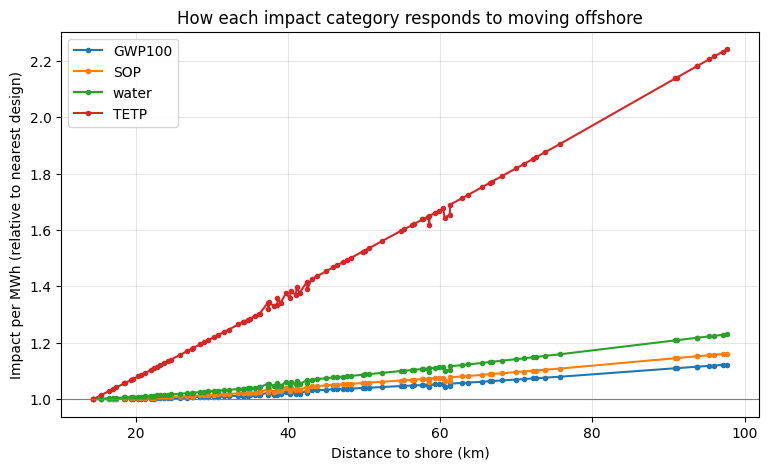

In [16]:
#@title All impact categories along the front
rows = []
for v in result.X:
    C, N, x, y, d = unpack(v)
    (neg_flh, _), _ = evaluate_design(v)
    aep_gwh = -neg_flh * N * C / 1000
    lifetime_mwh = aep_gwh * 1000 * LIFETIME_YR
    array_km = minimum_spanning_tree(squareform(pdist(np.column_stack([x, y])))).sum() / 1000
    t = turbine_impacts_cached(C)
    row = {"Capacity_MW": C, "Distance_km": d, "Full_load_hours": -neg_flh}
    for c in METHODS:
        total = (N * t[c]
                 + array_km * CABLE_IMPACT_PER_KM[ARRAY_CABLE][c]
                 + d * EXPORT_SHARE * CABLE_IMPACT_PER_KM[EXPORT_CABLE][c])
        row[f"{c}_per_MWh"] = total / lifetime_mwh
    rows.append(row)
impacts_front = pd.DataFrame(rows).sort_values("Distance_km").reset_index(drop=True)

# Each category relative to its value at the nearest-shore design
cols = [f"{c}_per_MWh" for c in METHODS]
rel = impacts_front[cols] / impacts_front[cols].iloc[0]

plt.figure(figsize=(9, 5))
for c in cols:
    plt.plot(impacts_front.Distance_km, rel[c], marker="o", ms=3, label=c.replace("_per_MWh", ""))
plt.axhline(1, color="grey", lw=0.8)
plt.xlabel("Distance to shore (km)"); plt.ylabel("Impact per MWh (relative to nearest design)")
plt.title("How each impact category responds to moving offshore")
plt.legend(); plt.grid(alpha=0.3)
plt.savefig(FIG / "08_categories_vs_distance.png", dpi=150, bbox_inches="tight")
plt.show()

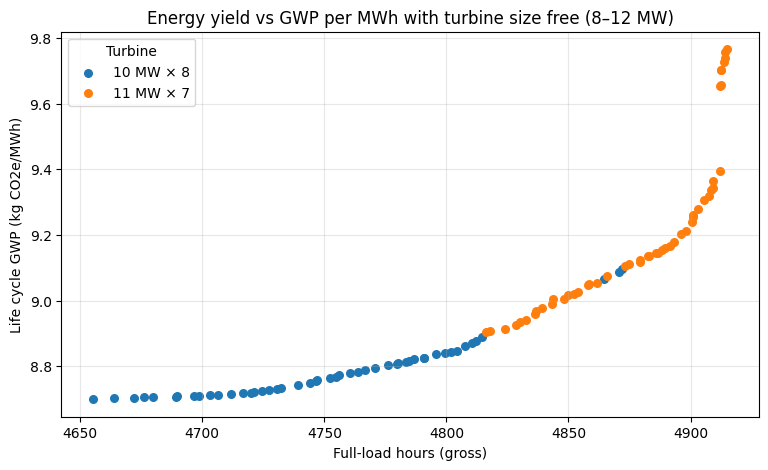

In [17]:
#@title Pareto front coloured by turbine size
plt.figure(figsize=(9, 5))
for C, grp in front.groupby("Capacity_MW"):
    plt.scatter(grp.Full_load_hours, grp.GWP_kg_per_MWh, s=30, label=f"{C} MW × {n_turbines(C)}")
plt.xlabel("Full-load hours (gross)"); plt.ylabel("Life cycle GWP (kg CO2e/MWh)")
plt.title("Energy yield vs GWP per MWh with turbine size free (8–12 MW)")
plt.legend(title="Turbine"); plt.grid(alpha=0.3)
plt.savefig(FIG / "08_sizing_front.png", dpi=150, bbox_inches="tight")
plt.show()

## What the front shows

The lowest-carbon design is 8 × 10 MW at 14.7 km offshore (8.71 kg CO2e/MWh), not at the 10 km bound
where LCOE is lowest in notebook 06: turbines are about 90 % of GWP, and the steeper near-shore wind
spreads that fixed burden over more energy. From there to 76 km, GWP per MWh rises 8 % while full-load
hours rise 5.6 %. Terrestrial ecotoxicity per MWh almost doubles over the same stretch, following the export
cable's copper. The front alternates between 10 MW and 11 MW turbines, which differ by under 1 % on both
objectives; 12 MW never appears, partly because 11 MW and 12 MW both round to 7 turbines in the same
fixed lease area.